Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0391 - val_loss: 0.0565
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0362 - val_loss: 0.0584
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0369 - val_loss: 0.0581
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0364 - val_loss: 0.0574
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0364 - val_loss: 0.0560
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0364 - val_loss: 0.0554
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0363 - val_loss: 0.0556
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0362 - val_loss: 0.0552
Epoch 9/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0363 - val_loss: 0.0553
Epoch 10/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0361 - val_loss: 0.0556
Epoch 11/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0362 - val_loss: 0.0579
Epoch 12/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0360 - val_l

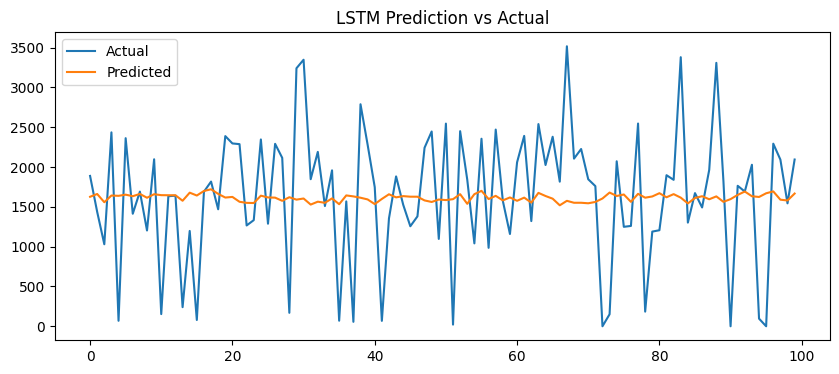

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
df = pd.read_csv("feature_engineered_data.csv")

# Select features
features = ['total_power', 'lag_1', 'lag_24', 'rolling_mean_24']
data = df[features]

# SCALING
feature_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(data)

target_scaler = MinMaxScaler()
scaled_target = target_scaler.fit_transform(df[['total_power']])

# CREATE SEQUENCES
sequence_length = 24

X = []
y = []

for i in range(sequence_length, len(scaled_features)):
    X.append(scaled_features[i-sequence_length:i])
    y.append(scaled_target[i])

X = np.array(X)
y = np.array(y)

# TRAIN TEST SPLIT
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# MODEL (SIMPLE & EFFECTIVE)
model = Sequential()
model.add(LSTM(50, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# TRAIN (LOW EPOCHS = SAFE)
model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

# PREDICTIONS
predictions = model.predict(X_test)

# INVERSE TRANSFORM
predictions = target_scaler.inverse_transform(predictions)
y_test_actual = target_scaler.inverse_transform(y_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse)

# PLOT
plt.figure(figsize=(10,4))
plt.plot(y_test_actual[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse)

LSTM RMSE: 853.8731936098936
